# <center>PIGS Monte Carlo for General Bose-Hubbard Systems</center>
#### <center>Liam Jones</center>
#### <center>PHY 411 - Spring 2025</center>

## Introduction

The Bose-Hubbard model is a bosonic tight binding model which is mostly known in condensed matter for its paradigmatic demonstration of the BKT phase transition from superfluidity to a Mott insulator phase. Its physics have even been realized experimentally using optical lattices, which have applications in certain trapped ion and neutral atom quantum computing architectures. Simulation of the model is often performed using density matrix renormalization group, but this method is often limited in applicability to just 1D systems. The path integral Monte Carlo (PIMC) method is better poised to handle higher-dimensional lattices.

In the summer of 2025, I worked on a PIMC algorithm which utilized ground state projection to study the Bose-Hubbard model at zero temperature. The algorithm is called Path Integral Ground State Monte Carlo for Lattice Implementations (PIGSFLI) and was developed by Emmanuel Casiano-Diaz at the University of Tennessee, Knoxville for his PhD thesis. My main contributions were the additions of particle density and one-body correlation matrix estimators along with open boundary conditions for the utilized hypercubic lattice geometries. The abstract for my results was as follows:

> The superfluid phase of the 1D Bose-Hubbard (BH) model at zero temperature can be described in the continuum by Luttinger liquid (LL) theory with bozonized phase and density fluctuations. For open boundary conditions (OBC), LL models predict Friedel oscillations in the ground state boson density due to breaking of translational symmetry. Motivated by such predictions, in this research we implement OBC in a zero-temperature path integral Monte Carlo (PIMC) algorithm for the BH model to study ground state observables. We benchmark energy and density estimators with OBC against exact diagonalization (ED) calculations and observe the expected error scaling with increasing projection length. Additionally, we introduce a one-body correlation matrix estimator implemented via non-canonical PIMC measurements. We then demonstrate Friedel oscillations in a 48-site system at quarter filling and perform non-linear fitting to a reduced functional form for comparison with LL theory predictions. The algorithm employed here is extensible to general dimensions for square lattices as well as to honeycomb, kagome, and other 2D lattice types, inviting discussion of future implementations.

The last sentence is where I have decided to pick back up with improving the algorithm. General lattices unlock much more interesting physics, but also require longer simulation times to converge. To balance these factors, benchmarking of the improved algorithm is to be performed for a 3x2 unit cell triangular lattice with open boundaries. This system includes all the new implemented features and their associated difficulties: non-uniform lattice dimensions, high coordination number for triangular lattice sites, and variation in the coordination number across sites introduced by open boundary conditions. The correlation matrix estimator has also been overhauled to improve sampling efficiency in the canonical ensemble, which benchmarking is to be performed in.

## Bose-Hubbard Model Exact Diagonalization

The Bose-Hubbard Hamiltonian in the lattice basis $\{|n_i\rangle\}$,
$$
H_{\text{BH}} = -t\sum_{\langle i,j\rangle} \left(b^{\dagger}_ib_j + b_ib^{\dagger}_j\right) + \frac{U}{2}\sum_i n_i(n_i-1) - \mu\sum_i n_i,
$$
describes interacting spinless bosons on a lattice of $M$ sites. In the canonical ensemble, the number of particles $N$ is fixed and the chemical potential term serves only to shift the energy by a constant. The kinetic term is a sum over nearest neighbors $\langle i,j\rangle$, which can be calculated in the form of an adjacency matrix. Conventionally, the repulsive on-site interaction is expressed as $U/t$. The on-site density is given by $n_i = b^{\dagger}_ib_i$, with $b^{\dagger}_i$ ($b_i$) the bosonic creation (annihilation) operators on site $i$. These obey the bosonic commutation relation $\left[b_i,b^{\dagger}_i\right]=\delta_{ij}$ and appear in the kinetic term in pairs as hopping operators. The one-body correlation matrix is defined by elements $C_{ij}=\left\langle b^{\dagger}_ib_j\right\rangle$; its diagonal elements are equivalent to the density.

The dimension of the Bose-Hubbard Hilbert space grows as
$$
D = \frac{(N+L-1)!}{N!(L-1)!} = \begin{pmatrix}N+L-1\\N\end{pmatrix}
$$
and thus exact diagonalization is only computationally feasible for small system sizes. Here, efficient Hamiltonian construction is performed using `LatticeModels.jl`. This package contains several pre-made lattice and Hamiltonian constructors for general lattice model implementations. The `eigs` function from `Arpack.jl` is used to compute ground state eigenstuff with the implicitly restarted Arnoldi/Lanczos method. The numerical accuracy of this method can be made sufficiently high so as to be considered essentially exact. Observables other than total energy can also be computed using the ground state wavefunction obtained from ED, as shown below.

In [1]:
# Multi-threaded kernel for reading and processing data
import IJulia
IJulia.installkernel("Julia (multi-threaded)", "--threads=auto")
println("Multi-threaded kernel installed. Switch to it and re-run the notebook.")
println("Active threads this session: $(Threads.nthreads())")

[ Info: Installing 'Julia (multi-threaded) 1.12' kernelspec in /Users/liamjones/Library/Jupyter/kernels/julia-_multi-threaded_-1.12


Multi-threaded kernel installed. Switch to it and re-run the notebook.
Active threads this session: 1


In [1]:
include("benchmarking_functions.jl")  # File containing all PIGSFLI benchmarking functions

Benchmarking functions loaded succesfully.

In [2]:
# ⟨E⟩ = ⟨K⟩ + ⟨V⟩
get_energies("triangular", [3, 2], 6, ["obc", "obc"], 1.0)  # 2D triangular lattice (3x2 unit cells) w/ 6 particles at U/t = 1.0

Dict{String, Float64} with 3 entries:
  "V" => 2.30099
  "E" => -16.5055
  "K" => -18.8065

In [3]:
# ⟨n_i⟩
get_densities("triangular", [3, 2], 6, ["obc", "obc"], 1.0)

Dict{String, Vector{Float64}} with 3 entries:
  "n^2"   => [0.857896, 1.72692, 2.71617, 2.71617, 1.72692, 0.857896]
  "σ^2_n" => [0.47365, 0.692271, 0.858546, 0.858546, 0.692271, 0.47365]
  "n"     => [0.619876, 1.01718, 1.36295, 1.36295, 1.01718, 0.619876]

In [4]:
# C_ij = ⟨b^†_i b_j⟩
get_corr_mat("triangular", [3, 2], 6, ["obc", "obc"], 1.0)

6×6 Matrix{Float64}:
 0.619876  0.787836  0.910959  0.904675  0.779729  0.607692
 0.787836  1.01718   1.16587   1.16318   0.999534  0.779729
 0.910959  1.16587   1.36295   1.34756   1.16318   0.904675
 0.904675  1.16318   1.34756   1.36295   1.16587   0.910959
 0.779729  0.999534  1.16318   1.16587   1.01718   0.787836
 0.607692  0.779729  0.904675  0.910959  0.787836  0.619876

## Path Integral Ground State Monte Carlo

MC methods perform the task of high-dimensional integration,
$$
I = \int d\mathbf{x}\, F(\mathbf{x}),
$$
by factoring the function of interest $F(\mathbf{x})$ into the product of some probability density $\pi(\mathbf{x})$ and a function $f(\mathbf{x})=F(\mathbf{x})/\pi(\mathbf{x})$:
$$
I = \int d\mathbf{x}\, f(\mathbf{x})\pi(\mathbf{x}) \equiv \langle f(\mathbf{x})\rangle.
$$
Then, for a large number of samples $N\gg1$ the integral is estimated as
$$
\langle f(\mathbf{x})\rangle \approx \frac{1}{N}\sum_{i=1}^N f(\mathbf{x}_i).
$$
The error on expectation values is then
$$
\sigma_f = \left[\frac{\langle f^2(\mathbf{x})\rangle - \langle f(\mathbf{x})\rangle^2}{N}\right]^{1/2}.
$$
Thus the expectation values become exact in the asymptotic limit $N\to\infty$.

To ensure convergence, the Markov chain used to generate samples must satisfy two conditions:

1. The existence of an equilibrium probability density; typically guaranteed via the principle of detailed balance, in which transitions during the Markov process occur with the same frequency as the inverse transition, i.e. $\pi(\mathbf{x})T(\mathbf{x}\to\mathbf{x}') = \pi(\mathbf{x}')T(\mathbf{x}'\to\mathbf{x})$.

2. Erdodicity - an infinitely long Markov chain should generate every possible configuration in an aperiodic way. In other words, a random walk by the Markov chain must be able to visit all configurations (to be discussed further below).

To satisfy detailed balance, the Metropolis-Hastings algorithm is used to generate samples from a probability density function $\pi(\mathbf{x}) = W(\mathbf{x})/\mathcal{Z}$, with $\mathcal{Z}$ a normalization constant. While $\mathcal{Z}$ is often difficult to compute in general, it is not necessary in Metropolis-Hastings where transition probabilities are factored as an a priori sampling probability $P(\mathbf{x}\to\mathbf{x}')$ and an acceptance probability $A(\mathbf{x}\to\mathbf{x}')$:
$$
T(\mathbf{x}\to\mathbf{x}') = P(\mathbf{x}\to\mathbf{x}')A(\mathbf{x}\to\mathbf{x}').
$$
Substitution of these factorized transition probabilities into the detailed balance equation yields
$$
W(\mathbf{x})A(\mathbf{x}\to\mathbf{x}')P(\mathbf{x}\to\mathbf{x}') = W(\mathbf{x}')A(\mathbf{x}'\to\mathbf{x})P(\mathbf{x}'\to\mathbf{x}),
$$
showing that the normalization drops out. A transition $\mathbf{x}\to\mathbf{x}'$ is accepted if a uniformly distributed random number $r\in[0,1]$ is less than an acceptance ratio
$$
R \equiv \frac{A(\mathbf{x}\to\mathbf{x}')}{A(\mathbf{x}'\to\mathbf{x})} = \frac{W(\mathbf{x}')P(\mathbf{x}'\to\mathbf{x})}{W(\mathbf{x})P(\mathbf{x}\to\mathbf{x}')}.
$$
Otherwise, the transition is rejected and the system remains in the same configuration.

In PIMC, the MC integration to be performed is a path integral over the configuration space of the lattice system in imaginary time. Furthermore, in path integral ground state MC (PIGS), the system is treated at zero temperature by projecting to the ground state. Projection of trial many-body wavefunctions on to the ground state of a system is described using the imaginary time propagator:
$$
    \ket{\Psi_0}\propto\lim_{\beta\to\infty}e^{-\beta H/2}\ket{\Psi_T} = \lim_{\beta\to\infty}\rho(\beta/2)\ket{\Psi_T},
$$
with $\beta$ commonly referred to as the projection length in this context. Convergence is guaranteed provided the trial wavefunction
$$
    \ket{\Psi_T} = \sum_{\alpha}c_{\alpha}\ket{\alpha}
$$
is not fully orthogonal to $\ket{\Psi_0}$. Here, the basis $\{\ket{\alpha}\}$ is chosen to partially diagonalize the many-body Hamiltonian $H=H_0+H_1$, with $H_0\ket{\alpha}=\epsilon_{\alpha}\ket{\alpha}$. The propagator in the interaction picture is then given by
$$
    \rho(\beta) = e^{-\beta H_0}T_{\tau}\exp\left(\int_0^{\beta} d\tau\, e^{H_0\tau}H_1e^{-H_0\tau}\right)
$$
where $T_{\tau}$ is the imaginary time ordering operator.

The goal of PIGS is to estimate ground state expectation values of physical observables by sampling worldline configurations. Here a wordline refers to the paths in imaginary time taken by particles through the configuration space, which may consist of, for example, a collection of lattice sites represented by Fock states. An observable $\mathcal{O}$ in the path integral picture can be expressed in terms of  the matrix elements of imaginary time propagators in the Fock basis:
$$
    \langle\mathcal{O}\rangle_0 = \frac{\langle\Psi_0|\mathcal{O}|\Psi_0\rangle}{\langle\Psi_0|\Psi_0\rangle} = \frac{1}{\mathcal{Z}_0}\lim_{\beta\to\infty}\sum_{\alpha_{\beta},\alpha'',\alpha',\alpha_0} c_{\alpha_{\beta}}^*c_{\alpha_0}\rho(\alpha'',\alpha_{\beta};\beta/2)\langle\alpha''|\mathcal{O}|\alpha'\rangle\rho(\alpha',\alpha_0;\beta/2)
$$
with $\rho(\alpha,\alpha';\beta)=\langle\alpha'|e^{-\beta H}|\alpha\rangle$. The ground state normalization may be written as
$$
    \mathcal{Z}_0 = \langle\Psi_0|\Psi_0\rangle = \lim_{\beta\to\infty}\sum_{\alpha_0,\alpha_{\beta}} c_{\alpha_{\beta}}^*c_{\alpha_0}\rho(\alpha_0,\alpha_{\beta};\beta) = \lim_{\beta\to\infty}\sum_{Q,\boldsymbol{\alpha}_Q}\int d\boldsymbol{\tau}_Q\, W_0(Q,\boldsymbol{\alpha}_Q,\boldsymbol{\tau}_Q),
$$
where $\boldsymbol{\alpha}_Q$ and $\boldsymbol{\tau}_Q$ are Fock states and imaginary times indexed by the kink (particle hopping) number $Q=0,1,\dots,\beta$. The configurational weights $W_0$ are given by the expansion
$$
    W_0(,\boldsymbol{\alpha}_Q,\boldsymbol{\tau}_Q) = c_{\alpha_{\beta}}^*c_{\alpha_0}(-1)^Qe^{-\epsilon_{\alpha_0}\tau_1}\prod_{q=1}^Q e^{-\epsilon_{\alpha_q}(\tau_{q+1}-\tau_q}(H_1^{\alpha_q,\alpha_{q-1}}+H_{\text{worm}}^{\alpha_q,\alpha_{q-1}}),
$$
where the additional term
$$
    H_{\text{worm}} = -\eta\sum_i \left(b_i^{\dagger}+b_i\right)
$$
comes from the insertion of worms - non-continuous paths in configuration space corresponding to the insertion of the single-particle imaginary time Green's function. The use of worms in PIGS enables native operation in the grand canonical ensemble, where the system particle number fluctuates.

Still, worms assist convergence in any statistical ensemble by ensuring ergodicity. This is because they are used to dynamically update wordline configurations in the sampling process. For finite temperature PIMC, where $\beta=1/k_BT$ is small, paths are treated as periodic in imaginary time and the collection of updates satisfying ergodicity are 

1. Insert/delete worm
2. Insert/delete antiworm
3. Advance/recede worm/antiworm
4. Insert/delete kink before head
5. Insert/delete kink after head
6. Insert/delete kink before tail
7. Insert/delete kink after tail

Here, the term antiworm serves to distinguish the case where the tail ($b^{\dagger}_i$; particle insertion) comes after the head ($b_j$; particle destruction) in imaginary time ($\tau_h<\tau_t$). A worm has instead has $\tau_t<\tau_h$ and removes a particle on site $i$ before creating one on site $j$. At zero temperature, additional updates are needed to ensure ergodicity as imaginary time is no longer periodic for $\beta\to\infty$:

8. Insert/delete worm/antiworm from $\tau=0$
9. Insert/delete worm/antiworm from $\tau=\beta$

These updates are implemented as functions in the file `updates.jl`.

Antiworms are necessary for measuring the one-body correlation matrix, and thus it is crucial that their insertion probabilities be high enough to collect the necessary measurements. This is achieved by tuning the parameter $\eta$, known as the worm fugacity, in $H_{\text{worm}}$ to allow insertions to be more energetically favourable. In this work, $\eta$ tuning is performed simultaneously with tuning of the chemical potential $\mu$ in a pre-equilibration stage for runs performed in the canonical ensemble. The file corresponding to this stage, `pre_equilibrate.jl`, implements projected stochastic approximation with Robbins-Monro step size scheduling to find fixed points of $\mu$ and $\eta$ which satisfy the target particle number and Z-sector sweep fraction, respectively. The Z-fraction is a user-provided input which specifies the ratio of MC sweeps spent with particle number fixed at $N$ to those where the particle number fluctuates (G-sector). Importantly, Z-fraction only affects sampling efficiency - for standard canonical measurements a value of ~50% is typical, while a run targeting non-canonical correlation matrix measurements may need a Z-fraction closer to ~20-30%.

Once pre-equilibration is complete, the second equilibration stage performs MC sweeps without measuring canonical obeservables. Here is where the efficiency improvement for the correlation matrix has been implemented: correlation measurements need not occur in the canonical sector where measurements of energy and density are performed and can thus be performed during equilibration sweeps. For runs where the correlation matrix is to be measured the number of equilibrium sweeps is doubled to increase the number of bins which can be filled before the main MC stage. This gives a substantial speedup over simply reducing the desired Z-fraction. To reduce overhead for writing and storing the correlation matrix, `pisfli.jl` and `monte_carlo.jl` have also been modified to write all measurement data to JLD2 files, which store Julia data structures in a fast binary serialization format.

## PIGSFLI Benchmarking

Benchmarking of the newly improved algorithm may now proceed for the system of interest: a 3x2 unit cell triangular lattice with open boundaries, shown below using the `TriangularLattice` constructor from `LatticeModels.jl`.

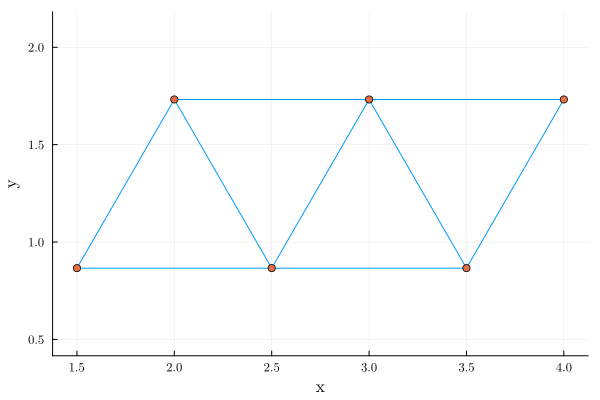

In [15]:
Plots.plot(TriangularLattice(3, 2))

Only a few additional simulation parameters need to be specified in addition to the system specifications. Initial values of $\mu$ and $\eta$ can both be specified as the starting points for `pre_equilibrate.jl`. Additionally, one can specify the trial state $|\Psi_T\rangle$ on which to perform the ground state projection. The trial state contributes a factor to the acceptance ratios for worldline updates involving the insertion/deletion of worms/antiworms from $\tau=0$ and $\tau=\beta$. Currently implemented trial states are `constant`, `non-interacting`, and `gutzwiller`. The `constant` state returns a flat value of 1 for its trial state factor. For the `non-interacting` state, different trial state factors in terms of the number of particles at $\tau=0,\beta$ and at the worm/antiworm tail are returned depending on the update being performed.

The `gutzwiller` trial state is only slightly more complex, being an implementation of the well-known Gutzwiller wavefunction often employed as a variational many-body state. Here, a coherent state anzatz is assumed such that the trial state
$$
|\Psi_G\rangle = \prod_i \sum_{n=0}^{n_\text{max}} f_n^{(i)}|n_i\rangle
$$
factorizes over lattice sites, with amplitudes normalized as
$$
\sum_{n=0}^{n_{\text{max}}} |f_n|^2 = \sum_{n=0}^{n_{\text{max}}} \left| \frac{\kappa^n}{\sqrt{n!}}\right|^2 = 1.
$$
For translationally invariant states, relevant for systems with sublattice structure, the amplitudes depend only on the sublattice index $\sigma$:
$$
f_n^{(\sigma)} \propto \frac{\kappa_{\sigma}^n}{\sqrt{n!}}.
$$
A mean-field decoupling may then be performed to compute the variational energy per unit cell. Use of a Gitzwiller state as the trial state greatly reduces the time to convergence compared to the non-interacting or constant states.

The function `optimize_gutzwiller` in `benchmarking_functions.jl` performs canonical Gutzwiller optimization for square, triangular, honeycomb, and kagome lattices - those which are provided as pre-defined lattice geometries in `adjacency_matrix.jl`. Using a nested scheme, the optimizer first bisects on the chemical potential $\mu$ to enforce the particle number then minimizes the variational energy over the trial state parameter $\kappa$ at fixed $\mu$. The results are then used as inputs for PIGSFLI runs, though in practice one may use a few trial runs to determine better starting values for $\mu$ since pre-equilibration performs optimization using real system dynamics.

In [8]:
optimize_gutzwiller("triangular", 1.0, 6, 6; n_max = 2)  # Triangular lattice, U/t = 1.0, N = 6, M = 6

(κ_opt = [1.1892071150021997], μ_opt = -0.7426406871236395, converged = true, sym_broken = false)

In [9]:
optimize_gutzwiller("honeycomb", 4.0, 9, 18; n_max = 2)  # Honeycomb lattice, U/t = 4.0, N = 9, M = 18

(κ_opt = [0.7406644114196732, 0.7406644114196733], μ_opt = 0.11017763492782251, converged = true, sym_broken = false)

In [10]:
optimize_gutzwiller("kagome", 3.3, 18, 27; n_max = 2)  # Kagome lattice, U/t = 3.3, N = 18, M = 27

(κ_opt = [0.8836155308732556, 0.8836155308732556, 0.8836155308732556], μ_opt = 0.047090593452594476, converged = true, sym_broken = false)

All that remains is to perform the MC runs at various values of the projection length $\beta$ to ensure convergence. The value of $\beta$ required to accurately obtain ground state observables scales roughly with the system size. In practice, one may perform several runs at low $\beta$ values then perform exponential fitting to extract the exact value. This assumes, of course, proper convergence, which is dependent on proper setting of trial states and simulation parameters as well as sufficient statistics to reduce uncertainty.

Example command line input (run in `/Pigsfli.jl`):

`julia pigsfli.jl -D 2 --Lx 3 --Ly 2 -N 6 --geometry "triangular" --boundary "obc" -U 1.0 --mu -1.86 --eta 0.02 --bin-size 500 --bins-wanted 5000 --beta 12.0 --get-density --get-corr-mat --trial-state gutzwiller --kappa 1.19 -Z 30.0 --seed 7005`

In [2]:
data = get_betas("triangular", [3, 2], 6, ["obc", "obc"], 1.0)  # Triangular lattice, 3x2 unit cells, N = 6, open boundaries, U/t = 1.0, β = 3.0, 6.0, 9.0
data[3]  # β = 9.0

Dict{String, Any} with 20 entries:
  "C"        => [0.498314 0.75031 … 0.764508 0.546051; 0.75031 0.981347 … 1.071…
  "V^2"      => 6.95924
  "V"        => 2.30027
  "K^2"      => 364.037
  "Ls"       => [3, 2]
  "N"        => 6
  "seeds"    => 501
  "geometry" => "triangular"
  "E^2"      => 283.985
  "bins"     => 5000
  "E"        => -16.5072
  "bcs"      => ["obc", "obc"]
  "C_bins"   => 2505000
  "beta"     => 9.0
  "U"        => 1.0
  "n^2"      => [0.860199, 1.73534, 2.70734, 2.70607, 1.73347, 0.85811]
  "n^2_stat" => [0.844486, 1.71404, 2.68199, 2.68087, 1.71223, 0.842395]
  "K"        => -18.8074
  "C^2"      => [0.523139 0.905978 … 0.934097 0.53614; 0.905978 1.49737 … 1.654…
  "n"        => [0.620301, 1.02024, 1.36091, 1.36078, 1.01856, 0.619214]

In [3]:
QMC_error(data[3])  # β = 9.0

Dict{String, Any} with 5 entries:
  "C" => [0.000331224 0.000370042 … 0.000373592 0.000308216; 0.000370042 0.0004…
  "V" => 0.00081601
  "K" => 0.00202944
  "E" => 0.00214244
  "n" => [0.00042839, 0.000518389, 0.000575586, 0.000575326, 0.000519009, 0.000…

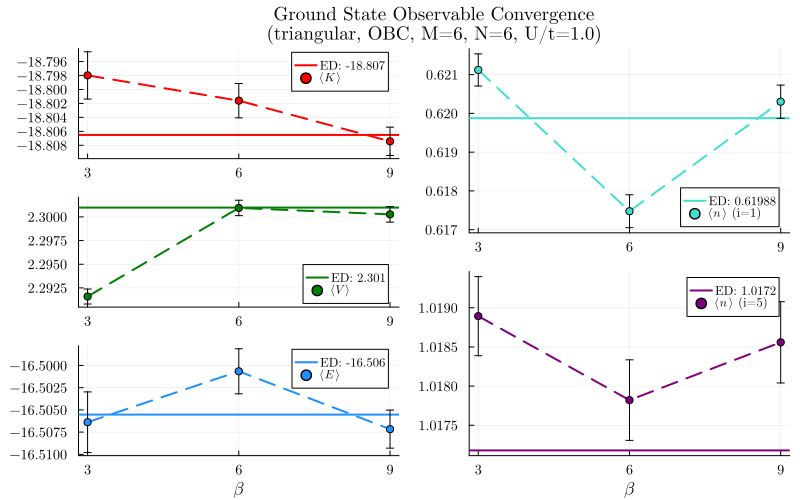

In [5]:
plot_betas(data; sites = [1, 5], extrapolate = false)

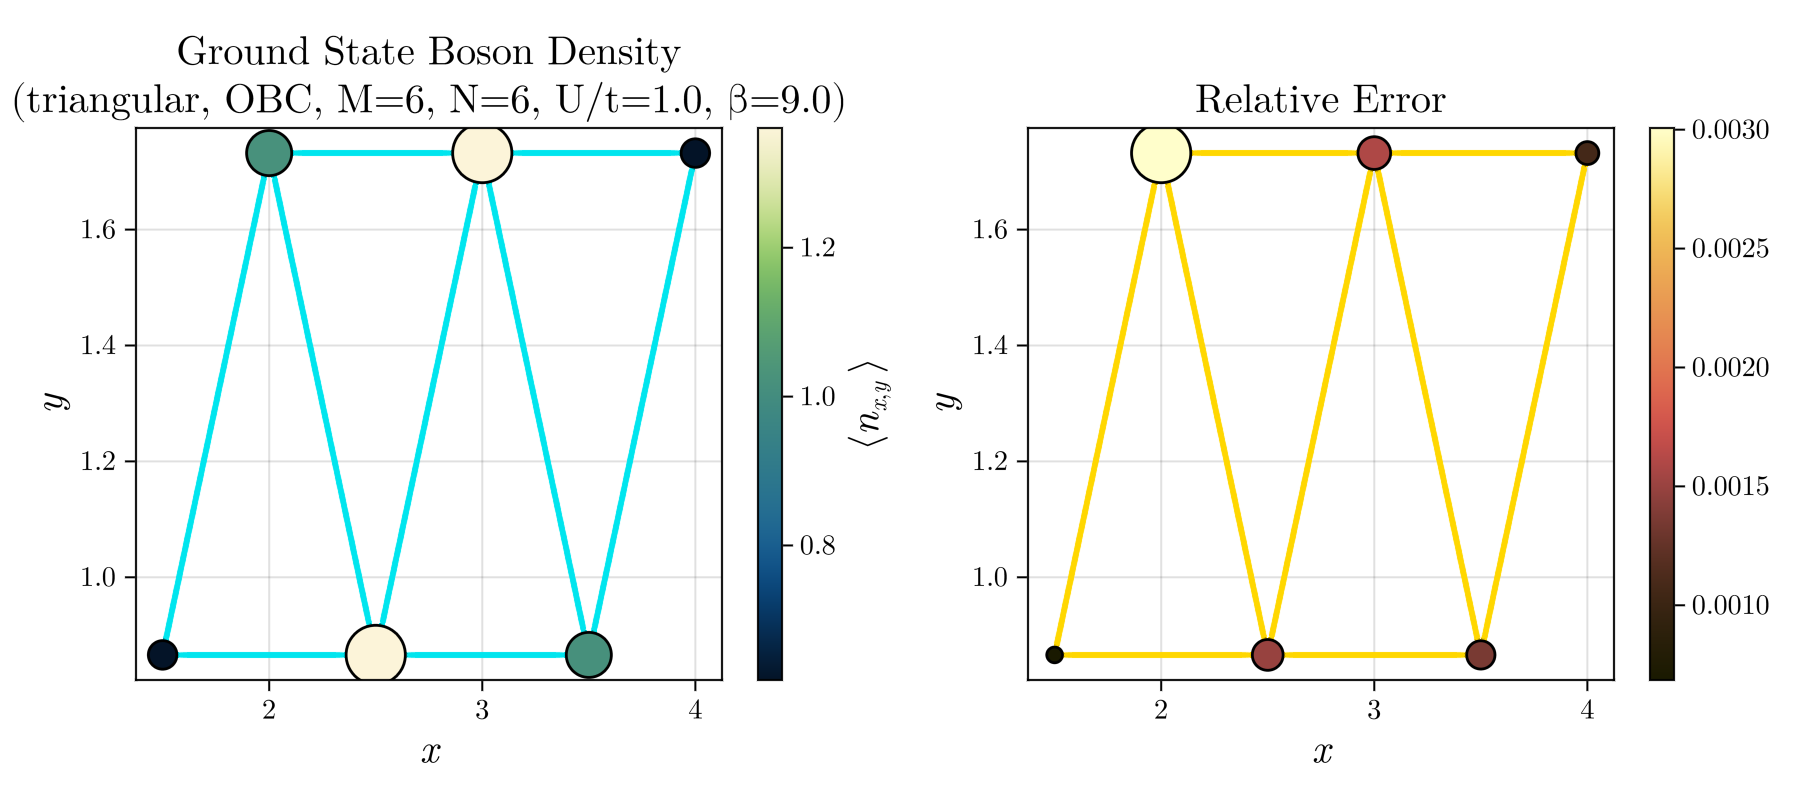

In [6]:
plot_density_2D(data[3])

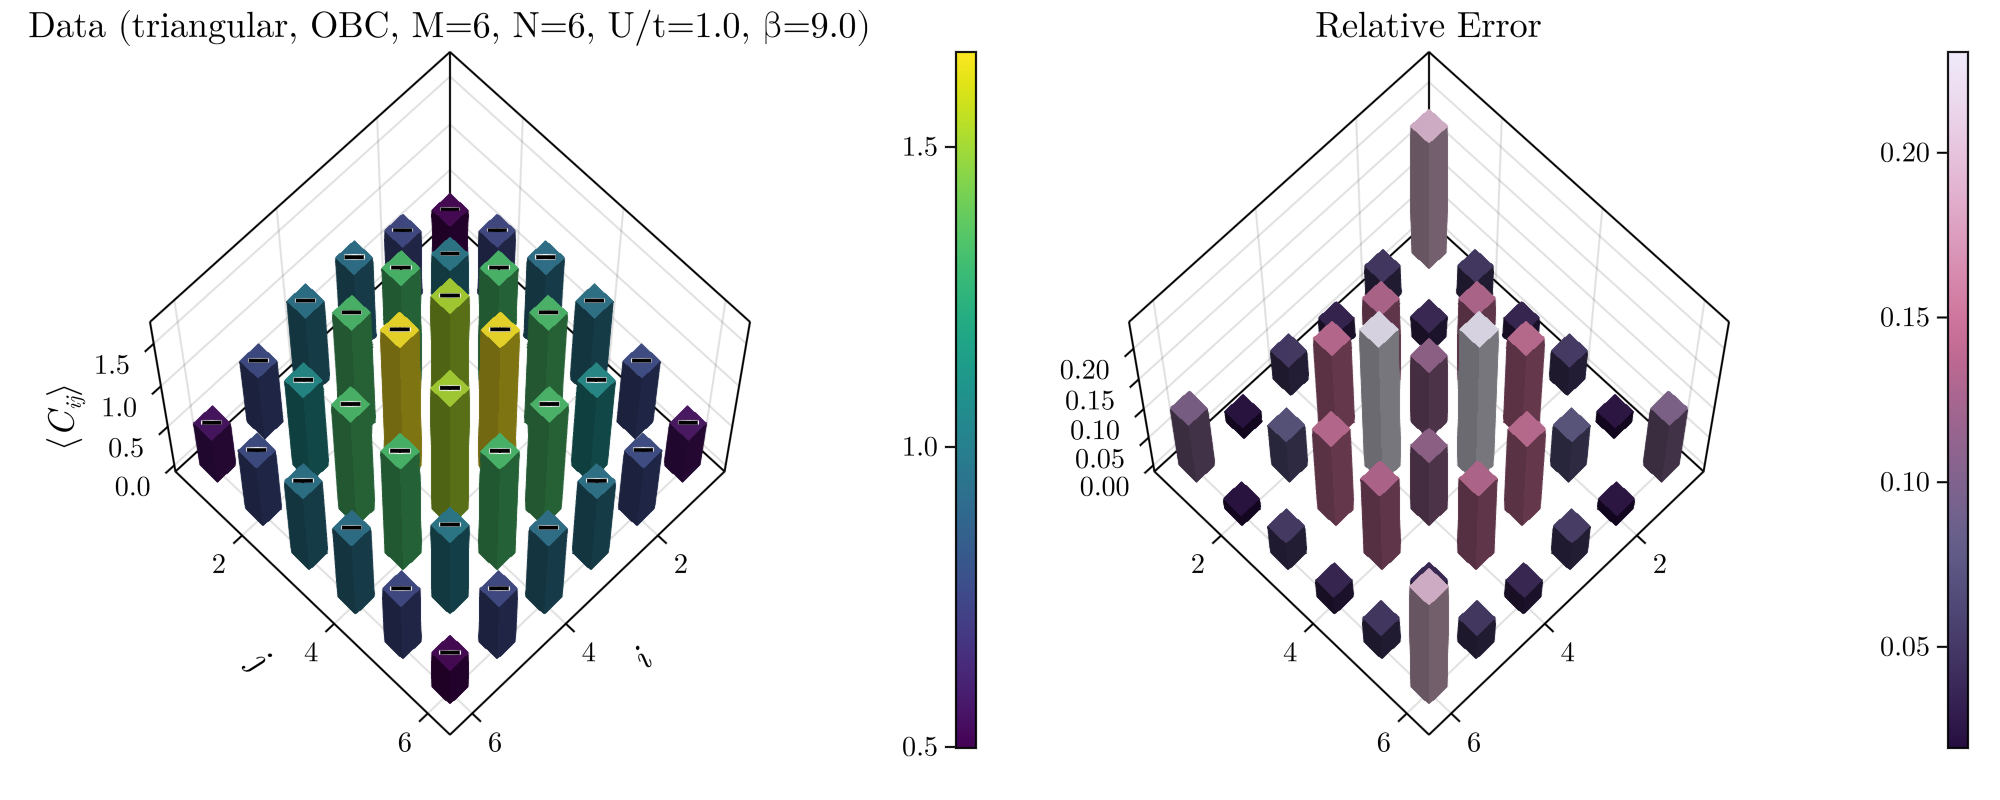

In [7]:
plot_corr_mat(data[3])

In [11]:
C_ij = data[3]["C"]

6×6 Matrix{Float64}:
 0.498314  0.75031   0.940129  0.949635  0.764508  0.546051
 0.75031   0.981347  1.32426   1.32991   1.07197   0.764681
 0.940129  1.32426   1.51988   1.65831   1.32981   0.950755
 0.949635  1.32991   1.65831   1.51955   1.32518   0.941402
 0.764508  1.07197   1.32981   1.32518   0.98193   0.750526
 0.546051  0.764681  0.950755  0.941402  0.750526  0.498974

In [13]:
C_ED = get_corr_mat("triangular", [3, 2], 6, ["obc", "obc"], 1.0)

6×6 Matrix{Float64}:
 0.619876  0.787836  0.910959  0.904675  0.779729  0.607692
 0.787836  1.01718   1.16587   1.16318   0.999534  0.779729
 0.910959  1.16587   1.36295   1.34756   1.16318   0.904675
 0.904675  1.16318   1.34756   1.36295   1.16587   0.910959
 0.779729  0.999534  1.16318   1.16587   1.01718   0.787836
 0.607692  0.779729  0.904675  0.910959  0.787836  0.619876

In [14]:
(C_ij .- C_ED) ./ C_ED

6×6 Matrix{Float64}:
 -0.196107   -0.0476309  0.0320215  0.0496966  -0.0195216  -0.101435
 -0.0476309  -0.0352266  0.135853   0.143336    0.0724717  -0.0192994
  0.0320215   0.135853   0.115144   0.230605    0.143248    0.0509352
  0.0496966   0.143336   0.230605   0.114905    0.136639    0.0334187
 -0.0195216   0.0724717  0.143248   0.136639   -0.0346531  -0.0473574
 -0.101435   -0.0192994  0.0509352  0.0334187  -0.0473574  -0.195042